<a href="https://colab.research.google.com/github/Kartikiscalm/IML-LAB-/blob/labs/Lab2_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Machine Learning Lab 2
## Linear Regression using Scikit-learn

**Course:** Introduction to Machine Learning
**Lab:** 2
**Topic:** Supervised Learning - Linear Regression
**Libraries used:** `numpy`, `pandas`, `matplotlib`, `scikit-learn`

---

**Instructions**

1. Run every cell in order, from top to bottom.
2. Read the Markdown explanation *before* running the code cell that follows it.
3. Sections 1 to 19 are guided material. Part I (Sections 6 to 9) builds Linear
   Regression from scratch with NumPy; Part II (Sections 10 to 14) repeats the same
   workflow using scikit-learn.
4. Section 20 contains the questions and lab tasks you must answer and submit.
5. Solutions are **not** included in this notebook. A separate solutions notebook
   will be released at the end of the week.

---
# 1. Introduction

In Lab 1 you became familiar with the Python scientific stack. In this lab you will
build your **first machine learning model**.

Instead of studying Linear Regression only as a formula on paper, you will learn it
through a concrete prediction problem:

> Given the **area of a house (in square feet)**, can we predict its
> **price (in lakhs)**?

This is a small problem, but it contains every ingredient of a real supervised
learning project: a dataset, an input, a target, a model, a training step, a
prediction step, and an evaluation step. Once you understand this pipeline, the same
pipeline transfers to problems of any size.

## 1.1 Learning Objectives

By the end of this lab you should be able to:

| # | You should understand |
|---|------------------------|
| 1 | What **supervised learning** is |
| 2 | What **regression** is, and how it differs from classification |
| 3 | What **features** and **target variables** are |
| 4 | What **Linear Regression** does |
| 5 | What the **coefficient (slope)** and **intercept** mean |
| 6 | Why we create **training** and **testing** datasets |
| 7 | What **model fitting** (`.fit()`) actually does |
| 8 | How to **predict** on new, unseen inputs (`.predict()`) |
| 9 | How to compute and read **MSE** |
| 10 | How to compute and read **RMSE** |
| 11 | How to compute and read the **R-squared score** |
| 12 | How to **visualise the regression line** |
| 13 | How to **interpret** what a trained model is telling you |

## 1.2 Setting Up

Run the cell below once. It imports every library used in this notebook.

In [ ]:
# Standard scientific Python stack
import numpy as np                 # numerical computing
import pandas as pd                # tabular data handling
import matplotlib.pyplot as plt    # plotting

# Part I of this lab uses NumPy only.
# The scikit-learn tools are imported later, at the start of Part II.

# Fixing the random seed so that every student obtains identical results
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


---
# 2. Technical Background

This section develops the theory you need **before** you implement anything.


Read this section carefully. Section 20 contains conceptual questions drawn
directly from it.

## 2.1 Machine Learning

### Traditional programming

In traditional programming, **the human writes the rules**. The computer applies them.

```text
Input  +  Rules (written by a programmer)   ->   Output
```

For example, to convert Celsius to Fahrenheit you write the rule yourself:
`F = C * 9/5 + 32`. This works because you already know the exact relationship.

### Machine Learning

Now consider predicting the price of a house from its area. Nobody can write down the
exact rule, because the relationship depends on the city, the market, the year and
many effects nobody has written a formula for.

Machine Learning inverts the arrangement. **The computer discovers the rules from
examples of inputs and their correct outputs.**

```text
Input  +  Output (examples)   ->   Rules (learned by the algorithm)
```

Once the rules are learned, they can be applied to inputs the computer has never seen.

### Supervised learning

**Supervised learning** is the branch of machine learning in which every training
example comes with its correct answer, called the **label** or **target**.

The word *supervised* refers to this answer key. The algorithm makes a guess, compares
it against the known correct answer, measures how wrong it was, and adjusts itself.

In this lab, each house in our dataset comes with both its area (the input) and its
actual price (the correct answer), so the problem is supervised.

### Regression vs classification

Supervised learning splits into two families, decided entirely by **what kind of
quantity the target is**:

| | Regression | Classification |
|---|---|---|
| Target is | A continuous number | A discrete category |
| Question asked | "How much?" / "How many?" | "Which class?" |
| Example target | 52.5 lakhs | `spam` / `not spam` |
| Other examples | Temperature tomorrow, exam marks, rainfall in mm | Disease present or absent, digit 0-9, pass or fail |

House price is a continuous number, so **this lab is a regression problem**.

## 2.2 Regression

**Concept.** Regression is the task of predicting a **continuous numerical quantity**
from one or more inputs.

**Intuition.** A continuous quantity is one that can, in principle, take any value in a
range, including fractional values. A house can cost 52 lakhs, or 52.4 lakhs, or
52.47 lakhs. There is no fixed list of allowed prices to choose from. Contrast this
with predicting whether an email is spam, where only two answers exist.

**Everyday examples of regression problems**

| Problem | Input (feature) | Output (target, continuous) |
|---|---|---|
| House price prediction | Area in square feet | Price in lakhs |
| Salary prediction | Years of experience | Annual salary |
| Sales prediction | Advertising expenditure | Units sold |
| Electricity consumption prediction | Outdoor temperature | Units consumed per day |

Notice that all four have the same shape. That is the point of this lab: you learn
**one** workflow and reuse it.

**Practical interpretation.** Because the output is a number, "correct" is not
yes-or-no. A prediction of 51.8 when the true price is 52.0 is not wrong; it is very
slightly off. Regression therefore needs error measures that quantify *how far off* a
prediction is. We define those in Sections 2.4 to 2.7.

## 2.3 Linear Regression

**Concept.** Linear Regression assumes the relationship between the input and the
output can be summarised by a **straight line**.

**Intuition.** Plot house area on the horizontal axis and house price on the vertical
axis. If larger houses tend to cost proportionally more, the points will scatter around
a line rising from left to right. Linear Regression finds the single straight line that
passes as close as possible to all the points at once.

### The school formula

You already know the equation of a straight line:

$$ y = mx + c $$

- $m$ is the slope: how much $y$ changes when $x$ increases by one unit.
- $c$ is the intercept: the value of $y$ when $x = 0$.

### The machine learning notation

The same line is written slightly differently in machine learning:

$$ \hat{y} = wx + b $$

Every symbol, defined immediately:

| Symbol | Name | Meaning in our problem |
|---|---|---|
| $x$ | **input feature** | Area of the house in square feet |
| $y$ | **actual target** | The true price of that house, taken from the dataset |
| $\hat{y}$ | **predicted target** ("y-hat") | The price the model predicts for area $x$ |
| $w$ | **coefficient** or **weight** | Learned slope: price added per extra square foot |
| $b$ | **intercept** or **bias** | Learned intercept: the value of $\hat{y}$ when $x = 0$ |

Two points deserve emphasis.

1. $y$ and $\hat{y}$ are **different quantities**. $y$ is the truth from the dataset;
   $\hat{y}$ is the model's guess. The whole of model evaluation is a comparison
   between these two.
2. $w$ and $b$ are **not supplied by you**. They are the numbers the algorithm
   *learns* from the training data. Learning a Linear Regression model means finding
   good values of $w$ and $b$, and nothing else.

### Reading the slope and intercept in the real world

Suppose training produces $w = 0.035$ and $b = 10$, giving

$$ \hat{y} = 0.035x + 10 $$

- **Slope $w = 0.035$:** each additional square foot of area is associated with an
  extra $0.035$ lakhs of price. Equivalently, 100 extra square feet is associated with
  about $3.5$ lakhs more. This is the number a buyer actually cares about.
- **Intercept $b = 10$:** the predicted price of a house of area $0$ square feet, which
  is $10$ lakhs.

The intercept illustrates an important habit of mind: a mathematically necessary
quantity is not always a physically meaningful one. A house of zero area does not
exist. The intercept is best read as the vertical offset that lets the line sit
correctly over the range of areas we actually observed, not as a real house price.

### How the line is chosen

Infinitely many straight lines can be drawn through a cloud of points. Linear
Regression picks the one that makes the **total squared error smallest**, a criterion
called **least squares**. Section 2.5 defines that error precisely.

For this lab, `scikit-learn` performs this minimisation for you when you call `.fit()`.

## 2.4 Prediction Error / Residual

**Concept.** A **residual** is the amount by which a single prediction misses the truth.

**Formula.** For the $i$-th observation:

$$ e_i = y_i - \hat{y}_i $$

**Definition of terms**

| Symbol | Meaning |
|---|---|
| $e_i$ | The residual (error) for observation $i$ |
| $y_i$ | The actual observed target value for observation $i$ |
| $\hat{y}_i$ | The value the model predicted for observation $i$ |
| $i$ | The index of the observation, $i = 1, 2, \ldots, n$ |
| $n$ | The number of observations |

**Intuition.** Draw the fitted line through your scatter plot. For each point, the
residual is the **vertical distance** from that point to the line.

**Practical interpretation.**

- $e_i > 0$: the model **under-predicted**. The real house was more expensive than
  predicted.
- $e_i < 0$: the model **over-predicted**. The real house was cheaper than predicted.
- $e_i = 0$: the point lies exactly on the line.

One residual describes one house. To judge the model as a whole we need to combine all
$n$ residuals into a single number, which is what the next three sections do.

## 2.5 Mean Squared Error (MSE)

**Concept.** MSE is the average of the squared residuals: a single number summarising
how wrong the model is across the whole dataset.

**Formula.**

$$ MSE = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2 $$

**Definition of terms**

| Symbol | Meaning |
|---|---|
| $n$ | Number of observations being evaluated |
| $y_i$ | Actual target value of observation $i$ |
| $\hat{y}_i$ | Predicted target value of observation $i$ |
| $\sum_{i=1}^{n}$ | Sum over all $n$ observations |
| $\frac{1}{n}$ | Divide by $n$ to obtain an average, so the value does not grow simply because the dataset is larger |

**Why are the errors squared?** Three reasons, in order of importance:

1. **To stop positive and negative errors cancelling.** If one house is
   over-predicted by 5 and another under-predicted by 5, the plain average error is
   $(-5 + 5)/2 = 0$, which falsely suggests a perfect model. Squaring makes every
   term non-negative, so errors accumulate instead of cancelling.
2. **To penalise large mistakes more heavily.** An error of 10 contributes 100, while
   an error of 2 contributes only 4. One badly wrong prediction therefore hurts far
   more than several slightly wrong ones. This matches the intuition that a house
   mispriced by 10 lakhs is worse than five houses each mispriced by 2 lakhs.
3. **It is smooth and easy to minimise**, which is exactly the criterion Linear
   Regression optimises (least squares).

**Practical interpretation.**

- MSE is always $\geq 0$.
- **Lower is better**; $MSE = 0$ means every prediction was exactly right.
- MSE has **squared units**. In our problem it is measured in "lakhs squared", which
  is not a quantity anybody can picture. This awkwardness motivates the next metric.

## 2.6 Root Mean Squared Error (RMSE)

**Concept.** RMSE is simply the square root of MSE.

**Formula.**

$$ RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2} $$

**Why take the square root?** Because it undoes the squaring and returns the error to
the **same unit as the target variable**.

| Metric | Unit in this problem | Can you interpret it directly? |
|---|---|---|
| MSE | (lakhs)$^2$ | No, squared rupees are not a familiar quantity |
| RMSE | lakhs | Yes |

**Practical interpretation.** If $RMSE = 2.4$, you can state plainly:

> "On average, the model's predicted house price is off by roughly 2.4 lakhs."

That sentence can be spoken to a non-technical person, which is precisely why RMSE is
usually the metric reported. Whether 2.4 lakhs is acceptable depends on the scale of
the prices: it is excellent if houses cost around 80 lakhs, and poor if they cost
around 6 lakhs. **Always compare RMSE against the typical size of the target.**

Note that RMSE inherits the sensitivity to large errors from MSE, since the squaring
happens before the square root.

## 2.7 R-squared Score (Coefficient of Determination)

**Concept.** MSE and RMSE tell you the size of the error in absolute units. $R^2$
answers a different question: **how much better is this model than the laziest possible
model?**

**The lazy baseline.** Suppose you refuse to look at the area at all, and predict the
**mean price** $\bar{y}$ for every house. That is the weakest sensible predictor.
$R^2$ measures how much of that baseline error your model has removed.

**Formula.**

$$ R^2 = 1 - \frac{\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2}{\sum_{i=1}^{n}\left(y_i - \bar{y}\right)^2} $$

**Definition of terms**

| Symbol | Meaning |
|---|---|
| $y_i$ | Actual target value of observation $i$ |
| $\hat{y}_i$ | Predicted target value of observation $i$ |
| $\bar{y}$ | The **mean** of the actual target values, $\bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i$ |
| $n$ | Number of observations |

The two sums have names worth knowing:

- Numerator $\sum (y_i - \hat{y}_i)^2$: the error **your model** still makes.
- Denominator $\sum (y_i - \bar{y})^2$: the error the **mean-only baseline** makes,
  which is the total variation present in the target.

So the fraction is "error left over, divided by error you started with", and $R^2$ is
one minus that: **the proportion of the variation in the target that the model
explains**.

**Practical interpretation**

| $R^2$ | Reading |
|---|---|
| $1.0$ | Perfect: every prediction exactly correct |
| $0.9$ | The model explains 90 percent of the variation in price |
| $0.0$ | The model is no better than always predicting the mean price |
| Negative | The model is **worse** than predicting the mean; something is wrong |

Unlike MSE and RMSE, $R^2$ has **no units**, so it can be compared across problems
measured in different quantities.

### Two cautions

**A high $R^2$ does not automatically mean the model is useful.** $R^2$ is computed
on a particular set of data. A model can score highly on the data it was trained on and
still fail on new houses, which is exactly why we hold out a test set in Section 6. A
high $R^2$ on a tiny test set is also weak evidence, simply because a handful of points
is easy to fit by luck.

**A high $R^2$ does not mean one variable causes the other.** $R^2$ only measures
whether two quantities move together. Ice cream sales and drowning incidents rise
together across the year and would give a respectable $R^2$, but ice cream does not
cause drowning; hot weather independently drives both. In our house problem, larger
area plausibly does raise price, but that judgement comes from knowledge of the
housing market, not from the value of $R^2$. **Correlation is not causation.**

## 2.8 How the Best Line Is Found: Least Squares

Section 2.3 said that Linear Regression picks the line minimising the total squared
error. That minimisation has an exact algebraic answer, so no searching or trial and
error is needed.

For a single feature, the values of $w$ and $b$ that minimise
$\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$ are:

$$ w = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}
\qquad\qquad
b = \bar{y} - w\bar{x} $$

**Definition of terms**

| Symbol | Meaning |
|---|---|
| $x_i$ | Feature value of observation $i$ (area of house $i$) |
| $y_i$ | Actual target value of observation $i$ (price of house $i$) |
| $\bar{x}$ | Mean of the feature values, $\bar{x} = \frac{1}{n}\sum x_i$ |
| $\bar{y}$ | Mean of the target values, $\bar{y} = \frac{1}{n}\sum y_i$ |
| $n$ | Number of training observations |

**Reading the formulas.**

The numerator of $w$ measures how $x$ and $y$ vary **together**: it is large and positive
when above-average areas tend to come with above-average prices. The denominator measures
how much $x$ varies **on its own**. So $w$ is "how much they move together, per unit of
how much $x$ moves" - exactly what a slope should be.

The formula for $b$ says the line must pass through the point $(\bar{x}, \bar{y})$, the
centre of the data. Once the slope is fixed, that requirement pins down the intercept.

**Why this matters for the lab.** These two formulas are the entire learning algorithm for
simple Linear Regression. In Part I you will implement them directly in NumPy and obtain
$w$ and $b$ yourself. In Part II you will call `.fit()` and get the same two numbers back.

---
# 3. Practical Use Case - House Price Prediction

We now build the model. The running example for the rest of the lab is:

> **Input (feature):** `Area_sqft`, the built-up area of a house in square feet
> **Output (target):** `Price_lakhs`, the price of that house in lakhs

The dataset is created directly in the notebook with `pandas`, so nothing has to be
downloaded and the lab runs identically on every machine.

There are 18 observations. Each row is one house: its area, and the price it actually
sold for. The prices rise with area but are not perfectly on a line, because real
prices also depend on locality, age, floor and negotiation. That leftover variation is
realistic and is exactly what the residuals in Section 13 will capture.

In [ ]:
# The house dataset is created directly inside the notebook.
# No external file or download is required.

df = pd.DataFrame({
    "Area_sqft": [600, 750, 800, 950, 1000, 1100, 1200, 1250, 1350,
                  1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200],
    "Price_lakhs": [31, 36, 39, 44, 45, 49, 52, 55, 58,
                    59, 63, 67, 69, 74, 76, 81, 83, 86]
})

df

,Area_sqft,Price_lakhs
0,600,31
1,750,36
2,800,39
3,950,44
4,1000,45
5,1100,49
6,1200,52
7,1250,55
8,1350,58
9,1400,59


---
# 4. Data Loading and Exploration

Before modelling anything, look at the data. This step is not optional. It is how you
catch a wrong column name, a missing value, an implausible number or a relationship
that is not linear at all, before you waste effort fitting a model that cannot work.

Three commands give a quick picture.

In [ ]:
# .head() shows the first 5 rows by default.
# Use it to confirm the column names and the general look of the data.
df.head()

,Area_sqft,Price_lakhs
0,600,31
1,750,36
2,800,39
3,950,44
4,1000,45


In [ ]:
# .shape returns a tuple: (number of rows, number of columns)
print("Shape of the dataset:", df.shape)
print("Number of houses (rows)   :", df.shape[0])
print("Number of columns         :", df.shape[1])

Shape of the dataset: (18, 2)
Number of houses (rows)   : 18
Number of columns         : 2


In [ ]:
# .describe() computes summary statistics for every numeric column.
df.describe()

,Area_sqft,Price_lakhs
count,18.000000,18.000000
mean,1400.000000,59.277778
std,483.857052,16.771143
min,600.000000,31.000000
25%,1025.000000,46.000000
50%,1375.000000,58.500000
75%,1775.000000,72.750000
max,2200.000000,86.000000


### Reading the outputs

**`df.head()`** confirms the table has the two columns we expect, `Area_sqft` and
`Price_lakhs`, and that the values are plausible numbers rather than text or blanks.

**`df.shape`** returns `(18, 2)`: 18 houses described by 2 columns. Always know how
much data you have. With only 18 rows we must be modest about how strongly we can
conclude anything.

**`df.describe()`** returns one column of statistics per numeric column:

| Statistic | Meaning |
|---|---|
| `count` | Number of non-missing values. If this is lower than `df.shape[0]`, values are missing |
| `mean` | Arithmetic average |
| `std` | Standard deviation, that is, how spread out the values are |
| `min`, `max` | Smallest and largest values. Useful for spotting impossible entries such as a negative area |
| `25%`, `50%`, `75%` | Quartiles. The `50%` value is the median |

Compare `mean` and `50%` (median): when they are close, the column is roughly
symmetric with no extreme outlier dragging the average.

### Why visualise before fitting

`LinearRegression` will fit a straight line to **any** data you hand it, whether or not
a straight line is a sensible description. It cannot refuse. The only way to know
whether a line is appropriate is to look.

A scatter plot answers three questions at once:

1. **Is there a relationship at all?** If the cloud is shapeless, no feature-based
   model will help.
2. **Is the relationship a straight line?** If the points curve, Linear Regression is
   the wrong tool and a different model is needed.
3. **Are there outliers?** A single distant point can pull the fitted line noticeably,
   especially in a dataset this small.

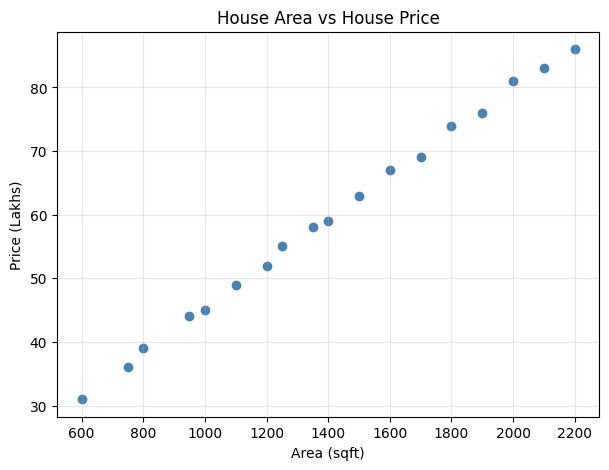

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Area_sqft"], df["Price_lakhs"], color="steelblue")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (Lakhs)")
plt.title("House Area vs House Price")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation of the scatter plot

The points rise steadily from left to right, so area and price show a clear
**positive relationship**: larger houses cost more. The rise looks close to
**straight**, not curved, so a straight-line model is a reasonable choice. The points
do not sit exactly on a line, which is expected in real data. No point sits far away
from the rest, so there is no obvious outlier.

We may proceed with Linear Regression.

---
# 5. Feature and Target Selection

Every supervised learning problem must be split into two roles.

| Role | Also called | Symbol | In this problem |
|---|---|---|---|
| **Feature** | Input, independent variable, predictor | `X` | `Area_sqft` |
| **Target** | Output, dependent variable, label, response | `y` | `Price_lakhs` |

The target is called *dependent* because its value is assumed to depend on the feature.
The feature is called *independent* because it is the quantity we supply.

Deciding which column is the target is a modelling decision made by you, not by the
algorithm. Here we predict price from area because at prediction time we will know the
area of a new house and want to estimate its price.

By long-standing convention `X` is written in **uppercase** and `y` in **lowercase**.
The convention reflects their shapes: `X` is a 2-dimensional table, `y` is a
1-dimensional column.

In [ ]:
X = df[["Area_sqft"]]    # feature: note the DOUBLE brackets
y = df["Price_lakhs"]    # target: single brackets

print("Type of X:", type(X).__name__)
print("Type of y:", type(y).__name__)

Type of X: DataFrame
Type of y: Series


In [ ]:
print("Shape of X:", X.shape)   # 2-dimensional: (rows, columns)
print("Shape of y:", y.shape)   # 1-dimensional: (rows,)

Shape of X: (18, 1)
Shape of y: (18,)


### Why does `X` use double brackets?

This is the single most common error beginners hit with `scikit-learn`, so it is worth
being precise.

- `df["Area_sqft"]` passes a **string**. Pandas returns a **Series**, which is
  1-dimensional with shape `(18,)`.
- `df[["Area_sqft"]]` passes a **list containing one string**. Pandas returns a
  **DataFrame**, which is 2-dimensional with shape `(18, 1)`.

Scikit-learn requires the feature matrix to be **2-dimensional**, shaped
`(n_samples, n_features)`. Rows are observations, columns are features. This design
exists so that the same code works unchanged when you later use several features:
`df[["Area_sqft", "Bedrooms", "Age"]]` gives shape `(18, 3)` and nothing else has to
change.

Because our problem has just one feature, the shape is `(18, 1)`: 18 samples, 1 feature.
The extra pair of brackets is what keeps that second dimension in place.

The target `y` is expected to be 1-dimensional, shape `(n_samples,)`, so single
brackets are correct there.

If you write `X = df["Area_sqft"]` by mistake, `model.fit()` raises an error saying it
expected a 2D array and received a 1D array instead. Recognising that message and
knowing the fix is part of the skill being taught here.

---
---
# PART I - Building Linear Regression From Scratch

Everything from here to Section 9 is written using **NumPy only**. No scikit-learn model
or metric is used in this part.

The point is that each step of the workflow is a short, readable piece of arithmetic. Once
you have written it yourself, the scikit-learn version in Part II is no longer a black box:
you will know exactly which lines of your own code each library function is replacing.

The four steps implemented here are:

| Step | What you will write |
|---|---|
| 6 | Splitting the data into training and test sets |
| 7 | Learning $w$ and $b$ with the least squares formulas |
| 8 | Predicting with $\hat{y} = wx + b$ |
| 9 | Computing MSE, RMSE and $R^2$ |

---
# 6. Train-Test Split From Scratch

### Why we split

Suppose you evaluate the model on exactly the same houses it learned from. The model has
already seen those prices, so scoring well shows only that it can reproduce what it was
shown. It says nothing about houses it has never encountered.

The property we care about is **generalization**: performing well on **new, unseen data**.
The standard defence is to hide part of the data from the model during training.

| Split | Purpose | Used during training? |
|---|---|---|
| **Training set** | The examples the model learns $w$ and $b$ from | Yes |
| **Test set** | Held back, used only to score the finished model | No |

### The algorithm

Splitting is just three steps:

1. Shuffle the row positions randomly, using a fixed seed so the result is reproducible.
2. Take the first 20 percent of the shuffled positions as the **test** set.
3. Take the rest as the **training** set.

In [ ]:
n_samples = len(df)
test_size = 0.2
n_test = int(np.ceil(test_size * n_samples))   # round up, as scikit-learn does

# A seeded random number generator: same seed -> same shuffle, every time
rng = np.random.RandomState(RANDOM_STATE)
shuffled = rng.permutation(n_samples)          # row positions in random order

test_pos  = shuffled[:n_test]                  # first 20% -> test
train_pos = shuffled[n_test:]                  # remainder -> train

print("Total rows      :", n_samples)
print("Test rows wanted:", n_test)
print()
print("Shuffled positions:", shuffled)
print("Test positions    :", test_pos)
print("Train positions   :", train_pos)

Total rows      : 18
Test rows wanted: 4

Shuffled positions: [ 0  1  8  5  3 13 16 15 11  2  9 17  4 12  7 10 14  6]
Test positions    : [0 1 8 5]
Train positions   : [ 3 13 16 15 11  2  9 17  4 12  7 10 14  6]


In [ ]:
# Use those positions to pull out the actual data.
# .iloc selects by POSITION (0, 1, 2, ...), which is what our shuffle produced.
X_train_scratch = X.iloc[train_pos]
X_test_scratch  = X.iloc[test_pos]
y_train_scratch = y.iloc[train_pos]
y_test_scratch  = y.iloc[test_pos]

print("Training set:", X_train_scratch.shape[0], "houses")
print("Test set    :", X_test_scratch.shape[0], "houses")
print()
print("Test houses held back:")
pd.DataFrame({
    "Area_sqft": X_test_scratch["Area_sqft"].values,
    "Price_lakhs": y_test_scratch.values
})

Training set: 14 houses
Test set    : 4 houses

Test houses held back:


,Area_sqft,Price_lakhs
0,600,31
1,750,36
2,1350,58
3,1100,49


### Notes on the code

**`np.random.RandomState(RANDOM_STATE)`** creates a random number generator seeded with
42. Seeding is what makes the split **reproducible**: every student running this notebook
shuffles the rows into exactly the same order, so everyone obtains the same coefficients
and the same metrics. Without a fixed seed, each run would give a different split.

**`rng.permutation(n_samples)`** returns the numbers $0$ to $n-1$ in random order. These
are row **positions**, not row labels.

**`np.ceil`** rounds up, so a 20 percent test share of 18 rows gives 4 test houses rather
than 3.

**`.iloc`** selects rows by position. We use it rather than `.loc` because our shuffled
values are positions.

Note that `X_train_scratch` keeps its 2-dimensional shape and `y_train_scratch` stays
1-dimensional, exactly as discussed in Section 5.

---
# 7. Training the Model From Scratch

Training means finding the $w$ and $b$ that minimise the squared error on the training
data. Section 2.8 gave the exact formulas:

$$ w = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}
\qquad\qquad b = \bar{y} - w\bar{x} $$

We now translate them directly into NumPy. Note that **only the training data is used**;
the test set takes no part in learning.

In [ ]:
# Work with plain 1-dimensional NumPy arrays for the arithmetic
x_tr = X_train_scratch["Area_sqft"].values.astype(float)
y_tr = y_train_scratch.values.astype(float)

# Step 1: the means
x_bar = x_tr.mean()
y_bar = y_tr.mean()

# Step 2: deviations from the mean
dx = x_tr - x_bar
dy = y_tr - y_bar

# Step 3: apply the formulas
numerator   = np.sum(dx * dy)      # how x and y vary together
denominator = np.sum(dx ** 2)      # how x varies on its own

w_scratch = numerator / denominator
b_scratch = y_bar - w_scratch * x_bar

print(f"x_bar (mean area)  : {x_bar:.4f}")
print(f"y_bar (mean price) : {y_bar:.4f}")
print(f"numerator          : {numerator:.4f}")
print(f"denominator        : {denominator:.4f}")
print()
print(f"w (coefficient)    : {w_scratch:.4f}")
print(f"b (intercept)      : {b_scratch:.4f}")
print()
print(f"Learned equation:  Price_lakhs = {w_scratch:.4f} * Area_sqft + {b_scratch:.4f}")

x_bar (mean area)  : 1528.5714
y_bar (mean price) : 63.7857
numerator          : 88835.7143
denominator        : 2593571.4286

w (coefficient)    : 0.0343
b (intercept)      : 11.4287

Learned equation:  Price_lakhs = 0.0343 * Area_sqft + 11.4287


### That is the whole learning algorithm

Six lines of arithmetic produced a trained model. There is no iteration and no search: the
least squares solution is a formula, so it is computed once and directly.

**Interpreting the coefficient.** Because $w$ is the change in $\hat{y}$ for a one-unit
increase in $x$, each additional square foot adds $w$ lakhs to the predicted price. A
square foot is a small unit, so scale it up to something you can picture.

In [ ]:
print(f"Price increase per 1 sqft    : {w_scratch:.4f} lakhs")
print(f"Price increase per 100 sqft  : {w_scratch * 100:.2f} lakhs")
print(f"Price increase per 500 sqft  : {w_scratch * 500:.2f} lakhs")

Price increase per 1 sqft    : 0.0343 lakhs
Price increase per 100 sqft  : 3.43 lakhs
Price increase per 500 sqft  : 17.13 lakhs


Because $w$ is **positive**, price rises with area, matching the upward trend in the
scatter plot.

**Interpreting the intercept.** $b$ is the predicted price when the area is 0 square feet.
No such house exists, so the intercept is not a real price. It is the vertical position
that best places the line over the range of areas we actually observed, roughly 600 to
2200 square feet.

---
# 8. Predicting From Scratch

Prediction is the direct application of the learned equation. Given any area $x$:

$$ \hat{y} = wx + b $$

This is one line of NumPy, and it works on a single value or a whole array at once.

In [ ]:
def predict_scratch(x, w, b):
    """Predict target values for feature values x using y_hat = w*x + b."""
    return w * np.asarray(x, dtype=float) + b


# Predictions for three new houses
new_areas = np.array([1100, 1600, 2200])
new_preds = predict_scratch(new_areas, w_scratch, b_scratch)

for area, price in zip(new_areas, new_preds):
    print(f"Area: {area:5d} sqft  ->  Predicted price: {price:6.2f} lakhs")

Area:  1100 sqft  ->  Predicted price:  49.11 lakhs
Area:  1600 sqft  ->  Predicted price:  66.23 lakhs
Area:  2200 sqft  ->  Predicted price:  86.78 lakhs


In [ ]:
# Predictions on the held-out test houses
x_te = X_test_scratch["Area_sqft"].values.astype(float)
y_te = y_test_scratch.values.astype(float)

y_pred_scratch = predict_scratch(x_te, w_scratch, b_scratch)

pd.DataFrame({
    "Area_sqft": x_te.astype(int),
    "Actual_Price": y_te,
    "Predicted_Price": np.round(y_pred_scratch, 2)
})

,Area_sqft,Actual_Price,Predicted_Price
0,600,31.0,31.98
1,750,36.0,37.12
2,1350,58.0,57.67
3,1100,49.0,49.11


### The prediction pipeline

```text
New Input
    |
    v
Trained model (the learned w and b)
    |
    v
Predicted Value
```

Training happens **once**; prediction can be repeated as often as you like on new inputs
and never changes the model.

**A caution about range.** The training areas ran from 600 to 2200 square feet. Predicting
at 1600 is **interpolation** and is well supported. Predicting at 9000 would be
**extrapolation**: the formula returns a number, but there is no evidence the straight-line
trend continues that far.

---
# 9. Evaluation Metrics From Scratch

We now implement the three metrics from Sections 2.5 to 2.7 directly from their formulas,
using the test predictions computed above.

In [ ]:
# Residuals: how far each prediction missed
residuals_scratch = y_te - y_pred_scratch

print("Actual    :", y_te)
print("Predicted :", np.round(y_pred_scratch, 2))
print("Residuals :", np.round(residuals_scratch, 2))

Actual    : [31. 36. 58. 49.]
Predicted : [31.98 37.12 57.67 49.11]
Residuals : [-0.98 -1.12  0.33 -0.11]


In [ ]:
# ---- Mean Squared Error:  MSE = (1/n) * sum( (y - y_hat)^2 ) ----
squared_errors = residuals_scratch ** 2
mse_scratch = np.mean(squared_errors)

# ---- Root Mean Squared Error:  RMSE = sqrt(MSE) ----
rmse_scratch = np.sqrt(mse_scratch)

# ---- R-squared:  R2 = 1 - SS_res / SS_tot ----
ss_res = np.sum((y_te - y_pred_scratch) ** 2)   # error the MODEL makes
y_test_mean = np.mean(y_te)
ss_tot = np.sum((y_te - y_test_mean) ** 2)      # error the MEAN-ONLY baseline makes
r2_scratch = 1 - ss_res / ss_tot

print("Squared errors :", np.round(squared_errors, 4))
print()
print(f"MSE  : {mse_scratch:.4f}")
print(f"RMSE : {rmse_scratch:.4f}")
print()
print(f"y_test mean (y_bar) : {y_test_mean:.4f}")
print(f"SS_res (numerator)  : {ss_res:.4f}")
print(f"SS_tot (denominator): {ss_tot:.4f}")
print(f"R2   : {r2_scratch:.4f}")

Squared errors : [0.9605 1.2496 0.1094 0.0113]

MSE  : 0.5827
RMSE : 0.7633

y_test mean (y_bar) : 43.5000
SS_res (numerator)  : 2.3308
SS_tot (denominator): 453.0000
R2   : 0.9949


### Reading the code against the formulas

<table style="width:100%; text-align:left;">
<tr>
<th>Formula</th>
<th>Code</th>
</tr>

<tr>
<td>$e_i = y_i - \hat{y}_i$</td>
<td><code>residuals_scratch = y_te - y_pred_scratch</code></td>
</tr>

<tr>
<td>$MSE = \frac{1}{n}\sum e_i^2$</td>
<td><code>np.mean(residuals_scratch ** 2)</code></td>
</tr>

<tr>
<td>$RMSE = \sqrt{MSE}$</td>
<td><code>np.sqrt(mse_scratch)</code></td>
</tr>

<tr>
<td>$SS_{res} = \sum (y_i - \hat{y}_i)^2$</td>
<td><code>np.sum((y_te - y_pred_scratch) ** 2)</code></td>
</tr>

<tr>
<td>$SS_{tot} = \sum (y_i - \bar{y})^2$</td>
<td><code>np.sum((y_te - y_test_mean) ** 2)</code></td>
</tr>

<tr>
<td>$R^2 = 1 - SS_{res}/SS_{tot}$</td>
<td><code>1 - ss_res / ss_tot</code></td>
</tr>
</table>

**Interpretation.** The RMSE is in lakhs, the same unit as the price, so it reads directly
as the typical size of the prediction error. The $R^2$ is the fraction of the variation in
test prices the model explains, relative to simply predicting the mean price every time.

Note that `ss_tot` uses the mean of the **test** targets, because that is the baseline we
are comparing against on the test set.

In [ ]:
print(f"Mean actual test price : {y_test_mean:.2f} lakhs")
print(f"RMSE                   : {rmse_scratch:.2f} lakhs")
print(f"RMSE as % of mean price: {100 * rmse_scratch / y_test_mean:.2f} %")
print()
print(f"The model explains {100 * r2_scratch:.2f}% of the variation in test-set prices.")

Mean actual test price : 43.50 lakhs
RMSE                   : 0.76 lakhs
RMSE as % of mean price: 1.75 %

The model explains 99.49% of the variation in test-set prices.


---
---
# PART II - The Same Workflow With Scikit-learn

Part I built a complete working Linear Regression in about thirty lines of NumPy. That was
worth doing once, because you now know precisely what the arithmetic is.

In practice nobody rewrites those lines for every project. `scikit-learn` provides tested,
optimised implementations of each step, and they extend to many features without any change
to your code.

This part repeats the **identical workflow** using the library. Each section states which
of your own lines the library call replaces, and finishes by checking that the two agree
numerically.

In [ ]:
# The scikit-learn tools used in this part
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("scikit-learn tools imported.")

scikit-learn tools imported.


---
# 10. Train-Test Split With Scikit-learn

**Replaces:** the shuffle, the `np.ceil` sizing and the two `.iloc` selections from
Section 6, that is, roughly eight lines, with one function call.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape[0], "houses")
print("Test set    :", X_test.shape[0], "houses")
print()
print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)

Training set: 14 houses
Test set    : 4 houses

X_train shape: (14, 1)
X_test  shape: (4, 1)
y_train shape: (14,)
y_test  shape: (4,)


### The two arguments

**`test_size=0.2`** is the fraction reserved for testing, replacing the `n_test`
calculation. A larger test set gives a more trustworthy score but leaves less data to
learn from; 0.2 to 0.3 is conventional.

**`random_state=42`** seeds the shuffle, replacing `np.random.RandomState(RANDOM_STATE)`.
It is what makes the split reproducible.

**Order of the outputs matters.** `train_test_split` always returns
`X_train, X_test, y_train, y_test` in that order. Swapping them produces a meaningless
model without raising an error.

### Does it match Part I?

`train_test_split` performs the same shuffle-then-slice procedure we wrote by hand, using
the same seeded generator. So the two splits should select exactly the same houses.

In [ ]:
same_train = sorted(X_train.index) == sorted(X_train_scratch.index)
same_test  = sorted(X_test.index)  == sorted(X_test_scratch.index)

print("Scratch test rows :", sorted(X_test_scratch.index.tolist()))
print("Sklearn test rows :", sorted(X_test.index.tolist()))
print()
print("Training sets identical:", same_train)
print("Test sets identical    :", same_test)

Scratch test rows : [0, 1, 5, 8]
Sklearn test rows : [0, 1, 5, 8]

Training sets identical: True
Test sets identical    : True


---
# 11. Building and Training the Model With Scikit-learn

**Replaces:** the means, deviations, numerator, denominator and both least squares
formulas from Section 7 with a single `.fit()` call.

Scikit-learn models always follow the same three-step pattern, which you will meet again
for every algorithm in this course:

```text
1. import the model class
2. create an instance          ->  model = LinearRegression()
3. fit it to the training data ->  model.fit(X_train, y_train)
```

In [ ]:
# Step 2: create the model object.
# At this moment the model is EMPTY: it has learned nothing yet.
model = LinearRegression()
print("Untrained model created:", model)

Untrained model created: LinearRegression()


In [ ]:
# Step 3: train (fit) the model on the TRAINING data only
model.fit(X_train, y_train)

print("Training complete. The model has now learned w and b.")

Training complete. The model has now learned w and b.


### What `.fit()` does

`LinearRegression()` creates an empty container: it knows the *form* $\hat{y} = wx + b$
but has no values. `.fit(X_train, y_train)` solves for the $w$ and $b$ that minimise the
total squared error, exactly the computation you performed in Section 7.

Two points to fix firmly in mind:

- **`.fit()` changes the model object in place.** Afterwards `model.coef_` and
  `model.intercept_` exist. The trailing underscore is a scikit-learn convention meaning
  "learned from data".
- **`.fit()` receives `X_train` and `y_train` only.** If test data leaked in, the later
  evaluation would no longer measure generalization.

In [ ]:
w = model.coef_[0]        # coef_ is an array, one entry per feature
b = model.intercept_      # intercept_ is a single number

print("Coefficient:", w)
print("Intercept:", b)
print()
print(f"Learned equation:  Price_lakhs = {w:.4f} * Area_sqft + {b:.4f}")

Coefficient: 0.0342522721013495
Intercept: 11.428669787937189

Learned equation:  Price_lakhs = 0.0343 * Area_sqft + 11.4287


`coef_` is an **array** because a model may have many features, one coefficient each. With
a single feature the array has length 1, so we take element `[0]`. `intercept_` is a single
number because a line has only one intercept.

### Does it match Part I?

In [ ]:
print(f"{'':<14}{'scratch':>12}{'sklearn':>12}")
print(f"{'coefficient':<14}{w_scratch:>12.6f}{w:>12.6f}")
print(f"{'intercept':<14}{b_scratch:>12.6f}{b:>12.6f}")
print()
print("Coefficients agree:", np.isclose(w_scratch, w))
print("Intercepts agree  :", np.isclose(b_scratch, b))

                   scratch     sklearn
coefficient       0.034252    0.034252
intercept        11.428670   11.428670

Coefficients agree: True
Intercepts agree  : True


---
# 12. Making Predictions With Scikit-learn

**Replaces:** your `predict_scratch` function with `.predict()`.

The input must have the **same structure as the training data**: a 2-dimensional table
with the same column name, `Area_sqft`. That is why we build a small DataFrame rather than
passing a bare list.

In [ ]:
new_houses = pd.DataFrame({
    "Area_sqft": [1100, 1600, 2200]
})

predictions = model.predict(new_houses)

for area, price in zip(new_houses["Area_sqft"], predictions):
    print(f"Area: {area:5d} sqft  ->  Predicted price: {price:6.2f} lakhs")

print()
print("Part I predictions for the same areas:", np.round(new_preds, 2))
print("Predictions agree:", np.allclose(new_preds, predictions))

Area:  1100 sqft  ->  Predicted price:  49.11 lakhs
Area:  1600 sqft  ->  Predicted price:  66.23 lakhs
Area:  2200 sqft  ->  Predicted price:  86.78 lakhs

Part I predictions for the same areas: [49.11 66.23 86.78]
Predictions agree: True


In [ ]:
# Predictions on the test set
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Area_sqft": X_test["Area_sqft"].values,
    "Actual_Price": np.array(y_test),
    "Predicted_Price": np.round(y_pred, 2)
})
comparison["Difference"] = (comparison["Actual_Price"]
                            - comparison["Predicted_Price"]).round(2)
comparison

,Area_sqft,Actual_Price,Predicted_Price,Difference
0,600,31,31.98,-0.98
1,750,36,37.12,-1.12
2,1350,58,57.67,0.33
3,1100,49,49.11,-0.11


---
# 13. Model Evaluation With Scikit-learn

**Replaces:** your squared-error, mean, square-root, `ss_res` and `ss_tot` calculations
from Section 9 with `mean_squared_error` and `r2_score`.

Note that scikit-learn has no separate RMSE function here, so we still take the square root
ourselves.

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

MSE  : 0.5827
RMSE : 0.7633
R2   : 0.9949


In [ ]:
print(f"{'':<8}{'scratch':>12}{'sklearn':>12}")
print(f"{'MSE':<8}{mse_scratch:>12.6f}{mse:>12.6f}")
print(f"{'RMSE':<8}{rmse_scratch:>12.6f}{rmse:>12.6f}")
print(f"{'R2':<8}{r2_scratch:>12.6f}{r2:>12.6f}")
print()
print("All three metrics agree:",
      np.allclose([mse_scratch, rmse_scratch, r2_scratch], [mse, rmse, r2]))

             scratch     sklearn
MSE         0.582696    0.582696
RMSE        0.763345    0.763345
R2          0.994855    0.994855

All three metrics agree: True


### Interpreting the metrics for this problem

**MSE** is the average squared gap between predicted and actual price. It is the quantity
the model minimises, and it is useful for comparing models on the same data. Its unit is
(lakhs)$^2$, so its value is not directly meaningful to a buyer.

**RMSE** converts that back into lakhs and is the metric to report: the predicted price is
off by about `rmse` lakhs on average. Judge it against the typical price, not in isolation.

**$R^2$** is the proportion of the variation in test prices the model explains, compared
with always predicting the mean price. A value near 1 means area alone accounts for most of
the variation, which matches the tight upward trend in the scatter plot.

Two reminders. These numbers come from only 4 test houses, so treat them as indicative; a
different `random_state` would shift them. And a high $R^2$ does not prove that area
*causes* price.

In [ ]:
mean_price = y_test.mean()
print(f"Mean actual test price : {mean_price:.2f} lakhs")
print(f"RMSE                   : {rmse:.2f} lakhs")
print(f"RMSE as % of mean price: {100 * rmse / mean_price:.2f} %")
print()
print(f"The model explains {100 * r2:.2f}% of the variation in test-set prices.")

Mean actual test price : 43.50 lakhs
RMSE                   : 0.76 lakhs
RMSE as % of mean price: 1.75 %

The model explains 99.49% of the variation in test-set prices.


---
# 14. Side by Side: What the Library Replaced

Both parts produced **identical numbers**, because they perform identical arithmetic. The
difference is only in how much of it you write.

| Step | Part I (NumPy) | Part II (scikit-learn) |
|---|---|---|
| Split | `rng.permutation`, `np.ceil`, two `.iloc` selections | `train_test_split(X, y, test_size=0.2, random_state=42)` |
| Train | means, deviations, numerator, denominator, two formulas | `model.fit(X_train, y_train)` |
| Inspect | `w_scratch`, `b_scratch` | `model.coef_[0]`, `model.intercept_` |
| Predict | `predict_scratch(x, w, b)` | `model.predict(X_test)` |
| MSE | `np.mean(residuals ** 2)` | `mean_squared_error(y_test, y_pred)` |
| RMSE | `np.sqrt(mse)` | `np.sqrt(mean_squared_error(...))` |
| $R^2$ | `1 - ss_res / ss_tot` | `r2_score(y_test, y_pred)` |

**Why use the library, given that the maths is this short?**

1. **It scales to many features.** Our formulas work for one feature only. `.fit()` handles
   any number without a change to your code, as you will see with the California data.
2. **It is tested and numerically careful.** Library code handles awkward cases such as
   near-zero denominators far more robustly than a direct translation of a formula.
3. **The interface is uniform.** Every model in scikit-learn uses `.fit()` and
   `.predict()`, so moving to a different algorithm changes one line.

**Why implement it once by hand anyway?** Because when a model behaves strangely, you need
to know what it is actually computing. `.fit()` is not magic; it is the two formulas from
Section 2.8.

From this point on we use the scikit-learn versions.

---
# 15. Regression Line Visualization

We now draw the line the model learned on top of the original data, which is the
clearest single picture of what Linear Regression has done.

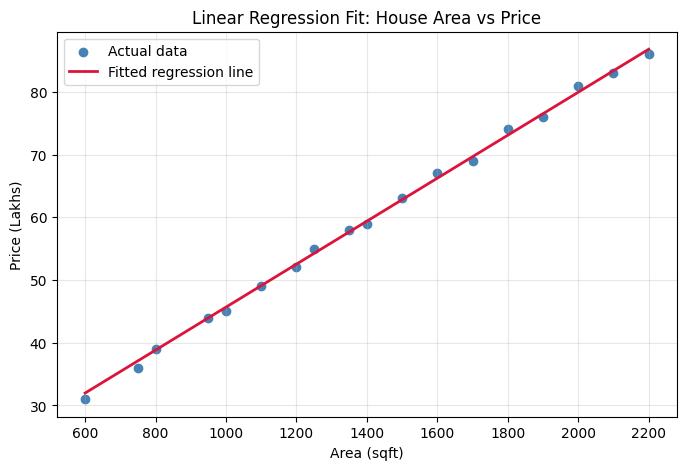

In [ ]:
# Predicted price for EVERY house in the full dataset,
# used only to draw the fitted line across the whole range of areas.
line_pred = model.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(df["Area_sqft"], df["Price_lakhs"],
            color="steelblue", label="Actual data")
plt.plot(df["Area_sqft"], line_pred,
         color="crimson", linewidth=2, label="Fitted regression line")

plt.xlabel("Area (sqft)")
plt.ylabel("Price (Lakhs)")
plt.title("Linear Regression Fit: House Area vs Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### What the regression line represents

The red line is the graph of the learned equation $\hat{y} = wx + b$. For **any** area
on the horizontal axis, the height of the line is the price the model predicts.

Read it as the model's summary of the general trend. Individual houses sit above or
below it because price is not determined by area alone; the vertical gap between a
point and the line is precisely the **residual** of Section 2.4.

Of all possible straight lines, this is the one for which the sum of those squared
vertical gaps, over the training houses, is as small as possible.

Points lying close to the line indicate the linear assumption is working. If instead
the points curved above the line at both ends and below in the middle, that systematic
pattern would tell you a straight line is the wrong shape for this data.

---
# 16. Actual vs Predicted Values

Aggregate metrics hide the individual cases. Placing actual and predicted prices side
by side shows *where* the model is doing well and where it is not.

In [ ]:
comparison = pd.DataFrame({
    "Area_sqft": X_test["Area_sqft"].values,
    "Actual_Price": np.array(y_test),
    "Predicted_Price": np.round(y_pred, 2)
})
comparison["Difference"] = (comparison["Actual_Price"]
                            - comparison["Predicted_Price"]).round(2)
comparison

,Area_sqft,Actual_Price,Predicted_Price,Difference
0,600,31,31.98,-0.98
1,750,36,37.12,-1.12
2,1350,58,57.67,0.33
3,1100,49,49.11,-0.11


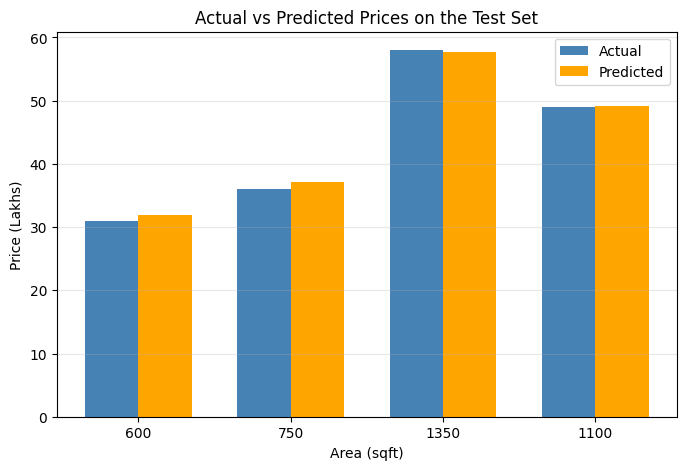

In [ ]:
# Bar chart: actual next to predicted for each test house
positions = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(positions - width/2, comparison["Actual_Price"],
        width, label="Actual", color="steelblue")
plt.bar(positions + width/2, comparison["Predicted_Price"],
        width, label="Predicted", color="orange")

plt.xticks(positions, comparison["Area_sqft"])
plt.xlabel("Area (sqft)")
plt.ylabel("Price (Lakhs)")
plt.title("Actual vs Predicted Prices on the Test Set")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.show()

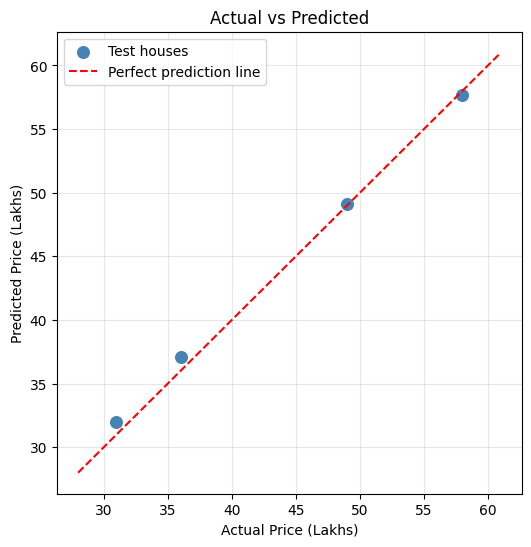

In [ ]:
# Scatter view: a perfect model would place every point on the diagonal
plt.figure(figsize=(6, 6))
plt.scatter(comparison["Actual_Price"], comparison["Predicted_Price"],
            color="steelblue", s=70, label="Test houses")

lo = min(comparison["Actual_Price"].min(), comparison["Predicted_Price"].min()) - 3
hi = max(comparison["Actual_Price"].max(), comparison["Predicted_Price"].max()) + 3
plt.plot([lo, hi], [lo, hi], "r--", linewidth=1.5, label="Perfect prediction line")

plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### What closeness means

In the **bar chart**, each pair of bars is one test house. Bars of nearly equal height
mean the prediction was nearly correct.

In the **scatter plot**, the dashed diagonal is the line
`Predicted = Actual`. A perfect model would place every point exactly on it.

- Point **above** the diagonal: the model **over-predicted** that house.
- Point **below** the diagonal: the model **under-predicted** it.
- Distance from the diagonal is the size of the error, which is the residual again,
  viewed from a different angle.

When predictions cluster tightly around the diagonal, the model has captured the
relationship well and its RMSE will be small relative to the prices. Watch also for
*systematic* patterns: if every expensive house fell below the line, the model would be
consistently under-pricing large houses, a defect that a single RMSE number would
conceal.

---
# 17. Residual Analysis

The residual for a house is, as defined in Section 2.4:

$$ \text{Residual} = \text{Actual} - \text{Predicted} = y_i - \hat{y}_i $$

Examining residuals is how you check the model rather than merely score it.

In [ ]:
residuals = np.array(y_test) - y_pred

residual_table = pd.DataFrame({
    "Area_sqft": X_test["Area_sqft"].values,
    "Actual": np.array(y_test),
    "Predicted": np.round(y_pred, 2),
    "Residual": np.round(residuals, 2)
})
residual_table

,Area_sqft,Actual,Predicted,Residual
0,600,31,31.98,-0.98
1,750,36,37.12,-1.12
2,1350,58,57.67,0.33
3,1100,49,49.11,-0.11


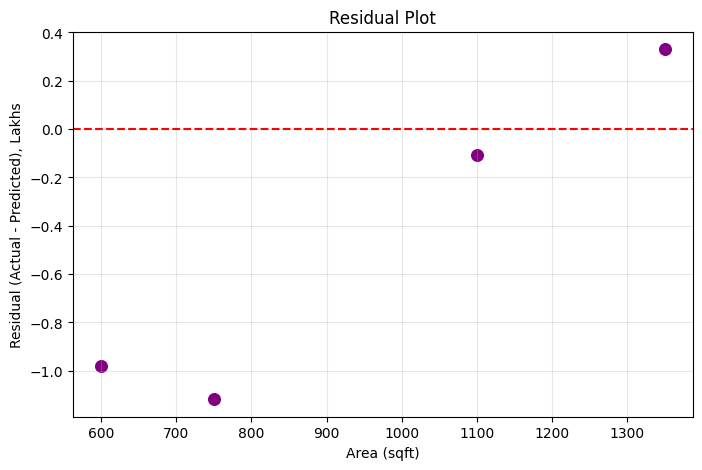

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test["Area_sqft"], residuals, color="purple", s=70)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5)

plt.xlabel("Area (sqft)")
plt.ylabel("Residual (Actual - Predicted), Lakhs")
plt.title("Residual Plot")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print(f"Mean residual    : {residuals.mean():.4f} lakhs")
print(f"Largest under-prediction (most positive): {residuals.max():.2f} lakhs")
print(f"Largest over-prediction  (most negative): {residuals.min():.2f} lakhs")

Mean residual    : -0.4683 lakhs
Largest under-prediction (most positive): 0.33 lakhs
Largest over-prediction  (most negative): -1.12 lakhs


### Reading the residual plot

The red dashed line marks zero error. Each point is one test house.

| Where the point sits | Meaning |
|---|---|
| Above the line (positive) | Actual price exceeded the prediction: **under-predicted** |
| Below the line (negative) | Actual price fell short of the prediction: **over-predicted** |
| On the line | Prediction was exact |

Two things are worth looking for.

**Are the residuals small relative to the prices?** Residuals of 2 lakhs on houses
costing 60 lakhs are minor. Residuals of 20 lakhs would not be.

**Are they scattered without pattern?** Residuals should be sprinkled randomly above
and below zero. Random scatter suggests the straight line has captured the systematic
part of the relationship, leaving only unpredictable variation. A visible pattern is a
warning: for example, residuals that are negative for small areas, positive in the
middle and negative again for large areas indicate a **curved** relationship that a
straight line cannot represent, and a different model would be needed.

We stop here. Formal statistical checking of regression assumptions belongs to a later
course; for this lab, the useful habit is simply to plot the residuals and look at them.

---
# 18. Generalization to Another Use Case

Nothing in Sections 5 to 13 was specific to houses. Linear Regression is a general tool
that applies wherever one continuous quantity moves roughly linearly with another.

To demonstrate this, here is the identical workflow applied to a completely different
problem:

> **Years of Experience -> Salary**

Only the dataset and the column names change. Every scikit-learn call is the same.

In [ ]:
# A second, unrelated dataset
exp_df = pd.DataFrame({
    "Years_Experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "Salary_lakhs":     [3.2, 4.0, 4.9, 5.5, 6.6, 7.1, 8.2, 8.8, 9.7, 10.5, 11.4, 12.0]
})

X_exp = exp_df[["Years_Experience"]]     # feature, 2-dimensional
y_exp = exp_df["Salary_lakhs"]           # target, 1-dimensional

X_exp_train, X_exp_test, y_exp_train, y_exp_test = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42
)

exp_model = LinearRegression()
exp_model.fit(X_exp_train, y_exp_train)

y_exp_pred = exp_model.predict(X_exp_test)

print(f"Coefficient : {exp_model.coef_[0]:.4f} lakhs per year of experience")
print(f"Intercept   : {exp_model.intercept_:.4f} lakhs")
print(f"RMSE        : {np.sqrt(mean_squared_error(y_exp_test, y_exp_pred)):.4f} lakhs")
print(f"R2          : {r2_score(y_exp_test, y_exp_pred):.4f}")

Coefficient : 0.8014 lakhs per year of experience
Intercept   : 2.4358 lakhs
RMSE        : 0.0932 lakhs
R2          : 0.9994


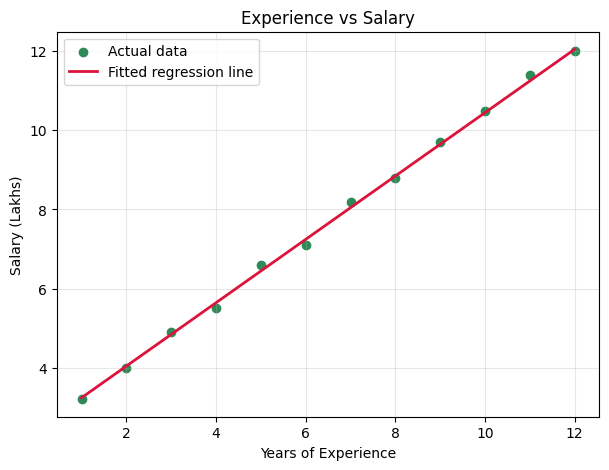

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(exp_df["Years_Experience"], exp_df["Salary_lakhs"],
            color="seagreen", label="Actual data")
plt.plot(exp_df["Years_Experience"], exp_model.predict(X_exp),
         color="crimson", linewidth=2, label="Fitted regression line")

plt.xlabel("Years of Experience")
plt.ylabel("Salary (Lakhs)")
plt.title("Experience vs Salary")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation

The coefficient now reads as **the salary increase associated with one additional year
of experience**, in lakhs. The intercept is the predicted salary at zero years, which
here is a rough estimate of a starting salary and is at least closer to being
meaningful than the zero-area house was.

The point of this section is that the *code* barely changed. Learn the workflow once,
and only the data and interpretation change from problem to problem.

### The general Linear Regression workflow

```text
Dataset
-> Select X and y
-> Explore Data
-> Train-Test Split
-> Create Model
-> Fit Model
-> Predict
-> Evaluate
-> Interpret
```

| Step | Code |
|---|---|
| Select X and y | `X = df[["feature"]]`, `y = df["target"]` |
| Explore data | `df.head()`, `df.describe()`, scatter plot |
| Train-test split | `train_test_split(X, y, test_size=0.2, random_state=42)` |
| Create model | `model = LinearRegression()` |
| Fit model | `model.fit(X_train, y_train)` |
| Predict | `model.predict(X_test)` |
| Evaluate | `mean_squared_error`, `np.sqrt`, `r2_score` |
| Interpret | Read `coef_`, `intercept_`, RMSE, $R^2$, residuals |

---
# 19. Feature Scaling (Normalization)

Features often live on very different scales. Area is in the hundreds or thousands, while
a "number of bedrooms" column would be in single digits. **Feature scaling** rewrites every
column onto a comparable range.

The two standard methods, both implemented from scratch below:

**Standardization (z-score)** centres each column at 0 with a spread of 1:

$$ z = \frac{x - \mu}{\sigma} $$

where $\mu$ is the column mean and $\sigma$ its standard deviation.

**Min-max scaling** squeezes each column into the interval $[0, 1]$:

$$ x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}} $$

In [ ]:
x_train_vals = X_train["Area_sqft"].values.astype(float)

# ---- Standardization from scratch ----
mu = x_train_vals.mean()
sigma = x_train_vals.std()
z_scratch = (x_train_vals - mu) / sigma

# ---- Min-max scaling from scratch ----
x_min, x_max = x_train_vals.min(), x_train_vals.max()
minmax_scratch = (x_train_vals - x_min) / (x_max - x_min)

print(f"mean (mu)      : {mu:.4f}")
print(f"std  (sigma)   : {sigma:.4f}")
print()
print("Original  :", np.round(x_train_vals[:6], 2))
print("z-score   :", np.round(z_scratch[:6], 4))
print("min-max   :", np.round(minmax_scratch[:6], 4))
print()
print(f"z-score  -> mean {z_scratch.mean():.4f}, std {z_scratch.std():.4f}")
print(f"min-max  -> min  {minmax_scratch.min():.4f}, max {minmax_scratch.max():.4f}")

mean (mu)      : 1528.5714
std  (sigma)   : 430.4127

Original  : [ 950. 1800. 2100. 2000. 1600.  800.]
z-score   : [-1.3442  0.6306  1.3276  1.0953  0.166  -1.6927]
min-max   : [0.1071 0.7143 0.9286 0.8571 0.5714 0.    ]

z-score  -> mean -0.0000, std 1.0000
min-max  -> min  0.0000, max 1.0000


### The scikit-learn equivalents

`StandardScaler` and `MinMaxScaler` do exactly this. They follow a `.fit()` then
`.transform()` pattern: `.fit()` learns $\mu$ and $\sigma$ (or the min and max) **from the
training data**, and `.transform()` applies them.

An important rule: the scaler is fitted on the **training set only**, then used to
transform both sets. Fitting it on all the data would leak information about the test set
into training.

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

std_scaler = StandardScaler().fit(X_train)      # learns mu and sigma from training data
z_sklearn = std_scaler.transform(X_train).ravel()

mm_scaler = MinMaxScaler().fit(X_train)
minmax_sklearn = mm_scaler.transform(X_train).ravel()

print("z-score  agree:", np.allclose(z_scratch, z_sklearn))
print("min-max  agree:", np.allclose(minmax_scratch, minmax_sklearn))
print()
print("scratch z:", np.round(z_scratch[:4], 6))
print("sklearn z:", np.round(z_sklearn[:4], 6))

z-score  agree: True
min-max  agree: True

scratch z: [-1.344225  0.630624  1.327629  1.095294]
sklearn z: [-1.344225  0.630624  1.327629  1.095294]


### Does scaling improve this model?

A fair question, and the answer here is **no**. Let us check rather than assume.

In [ ]:
scaled_model = LinearRegression().fit(std_scaler.transform(X_train), y_train)
y_pred_scaled = scaled_model.predict(std_scaler.transform(X_test))

print(f"Unscaled : coefficient {model.coef_[0]:>10.4f} | R2 {r2_score(y_test, y_pred):.6f}")
print(f"Scaled   : coefficient {scaled_model.coef_[0]:>10.4f} | R2 {r2_score(y_test, y_pred_scaled):.6f}")
print()
print("Predictions identical:", np.allclose(y_pred, y_pred_scaled))

Unscaled : coefficient     0.0343 | R2 0.994855
Scaled   : coefficient    14.7426 | R2 0.994855

Predictions identical: True


### Interpretation

The predictions are **identical** and the $R^2$ is unchanged. Only the coefficient changed,
because it now expresses "lakhs per standard deviation of area" rather than "lakhs per
square foot".

This is not a quirk of our data. `LinearRegression` solves the least squares equations
exactly, and that solution is unaffected by a linear rescaling of the inputs. **Scaling
cannot help ordinary Linear Regression.**

So why learn it? Because it becomes essential very soon:

| Situation | Why scaling matters |
|---|---|
| **Gradient descent** | An unscaled feature makes the optimiser take badly-shaped steps and converge slowly or not at all |
| **Regularization** (Ridge, Lasso) | The penalty applies to coefficient size, so unscaled features are penalised unfairly |
| **Distance-based models** (kNN, SVM, k-means) | Distances are dominated by whichever feature has the largest numbers |
| **Comparing coefficients** | With features on one scale, coefficient sizes become comparable measures of influence |

The rule to remember: scaling is about the **algorithm**, not the data. Ordinary Linear
Regression does not need it; most of what comes next does.

---
---
# 20. Questions and Lab Tasks

**This section is for self-assesment.**

Answer all questions. Write conceptual answers in Markdown cells and code answers in code cells, immediately below the question. Keep the question numbering.

Solutions are **not** provided in this notebook. A separate solutions notebook will be released; use it to check your work (by yourself) only after you have
attempted everything yourself.

## 20.1 Conceptual Questions

Answer each in two to five sentences of your own words.

**Q1.** What is the difference between regression and classification? Give one example
of each that is not taken from this notebook.


**Q2.** In the house-price example used in this lab, identify the **feature** and the
**target**. State which is the independent variable and which is the dependent
variable, and explain why the roles are assigned that way.

**Q3.** Why do we split the data into training and testing sets? What could go wrong if
a model were evaluated only on the data it was trained on?

**Q4.** In the MSE formula, why are the errors **squared**? Give at least two distinct
reasons.

**Q5.** Why is RMSE often easier to interpret than MSE? Illustrate your answer using
the units of the house-price problem.

**Q6.** What does the $R^2$ score tell us? What does $R^2 = 0$ mean, and what would a
**negative** $R^2$ indicate?

**Q7.** Why does a high $R^2$ not necessarily imply that the feature **causes** the
target? Give an example of two quantities that would be strongly related without one
causing the other.

## 20.2 Code Understanding Questions

For each snippet, explain **what the line does**, **what object or value it produces**,
and, where asked, what would go wrong if it were written differently.

**Q8.** Explain each part of the following line, including what the four returned
objects are, what `test_size` controls, and what `random_state` controls.

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```

**Q9.** What does the following line do? What changes about the `model` object as a
result? Why is `X_test` deliberately **not** passed to it?

```python
model.fit(X_train, y_train)
```

**Q10.** What does the following line return, and what is the shape of the result?
Does calling it modify the model in any way?

```python
y_pred = model.predict(X_test)
```

**Q11.** Explain what each of these returns and why the first has an index `[0]` while
the second does not.

```python
model.coef_[0]
model.intercept_
```

**Q12.** A student writes the code below and receives an error from scikit-learn.
State what the error is about and how to fix it in one line.

```python
X = df["Area_sqft"]
y = df["Price_lakhs"]
model.fit(X, y)
```

**Q13.** Two students run the entire notebook on different laptops. One uses
`random_state=42` and the other uses `random_state=7`. They obtain different values of
RMSE. Explain why, and state whether either student has made a mistake.

## 20.3 Numerical Questions

Work these **by hand**, showing every step. Do not use scikit-learn. You may use a
calculator, and you may verify your answers with Python afterwards, but the worked
steps must be your own.

All four questions below refer to the same trained model and the same three houses.

Suppose a Linear Regression model has been trained and learned:

$$ \hat{y} = 0.04x + 8 $$

where $x$ is the area in square feet and $\hat{y}$ is the predicted price in lakhs.

Three houses have the following actual prices:

| House | Area $x$ (sqft) | Actual price $y$ (lakhs) |
|---|---|---|
| A | 1000 | 50 |
| B | 1500 | 65 |
| C | 2000 | 89 |

**Q14. Predictions and residuals.**

(a) Compute the **predicted price** $\hat{y}$ for each of the three houses.

(b) Compute the **residual** $e_i = y_i - \hat{y}_i$ for each house. State for each house
whether the model over-predicted or under-predicted, and justify your answer from the
sign.

**Q15. Error metrics.**

(a) Compute the **MSE** across the three houses. Show the squared errors before
averaging.

(b) Compute the **RMSE**. State its unit and write one sentence interpreting it in plain
language for a house buyer.

**Q16. Goodness of fit.**

Compute the **$R^2$ score** for these three houses. You will need $\bar{y}$, the mean of
the actual prices. Show the numerator and denominator sums separately, then state in one
sentence what your value means.

**Q17. Predicting beyond the data.**

Using the same model $\hat{y} = 0.04x + 8$, predict the price of a house of area
**2500 sqft**. Then state a reason why this prediction should be treated with more
caution than the prediction for house B.

## 20.4 Practical Coding Task: California Housing

Everything so far used a small dataset created inside the notebook, which made it easy
to see every row at once. Real datasets are larger, have many columns, and are loaded
from a source rather than typed out.

This exercise moves you onto a genuine dataset while keeping the workflow identical.
The **California Housing** dataset ships with `scikit-learn` and describes housing in
California districts from the 1990 census. Each row is a **district**, not a single
house.

Run the cell below to download and load it. The download happens once and is then
cached on your machine.

In [ ]:
from sklearn.datasets import fetch_california_housing

# as_frame=True asks scikit-learn to return the data as a pandas DataFrame
housing = fetch_california_housing(as_frame=True)

# The full table: 8 feature columns plus the target column MedHouseVal
cal_df = housing.frame

print("Shape of the California Housing dataset:", cal_df.shape)
print()
print("Feature names:", housing.feature_names)
print("Target name  :", housing.target_names)

Shape of the California Housing dataset: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target name  : ['MedHouseVal']


### About this dataset

The table has **20640 rows** and **9 columns**: 8 features and 1 target.

| Column | Meaning |
|---|---|
| `MedInc` | Median income of households in the district (in tens of thousands of dollars) |
| `HouseAge` | Median age of the houses in the district, in years |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | Total population of the district |
| `AveOccup` | Average number of household members |
| `Latitude` | Latitude of the district |
| `Longitude` | Longitude of the district |
| **`MedHouseVal`** | **Target:** median house value in the district, in hundreds of thousands of dollars |

So a `MedHouseVal` of `2.5` means 250000 dollars, and a `MedInc` of `3.0` means a
median income of 30000 dollars.

For this exercise use a **single feature**, `MedInc`, to predict `MedHouseVal`. Median
income is the feature most strongly related to house value, and using one feature keeps
the regression line plot from Section 15 available to you.

Two differences from the tutorial dataset to keep in mind while you work:

- It is roughly a thousand times larger, so printing the whole table is not useful.
  Rely on `.head()`, `.shape` and `.describe()`.
- It is **real data**, so the points will scatter far more widely around the line than
  the tidy house dataset did. Expect a noticeably lower $R^2$, and do not treat that as
  a mistake on your part.

### Tasks

The five questions below walk through the same workflow you followed in Parts I and II,
this time on real data. Use the variable names suggested so that your work is easy to
compare against the solutions.

**Q18. Load and explore the data.**

(a) Inspect the data. Display `cal_df.head()`, print `cal_df.shape`, and display
`cal_df.describe()`. Then write one or two sentences on what `.describe()` tells you. In
particular, look at the `min` and `max` of `MedHouseVal` and comment on anything that
looks unusual about the maximum.

(b) Visualize the relationship between `MedInc` and `MedHouseVal` with a scatter plot,
with axis labels and a title. With 20640 points the plot will be crowded, so pass
`alpha=0.2` and `s=5` to `plt.scatter` to make the density visible. Describe the
relationship you see, and say whether a straight-line model looks reasonable.

**Q19. Prepare the data.**

(a) Define the feature matrix and target:

```python
X_cal = ...   # use only the MedInc column
y_cal = ...   # MedHouseVal
```

Print the shape of each, and state which is the independent and which the dependent
variable.

(b) Split the data using `test_size=0.2` and `random_state=42`, naming the outputs
`X_cal_train, X_cal_test, y_cal_train, y_cal_test`. Print how many districts end up in
each set.

(c) **From scratch.** Reproduce the same split using NumPy only, following the method of
Section 6: seed a generator with `np.random.RandomState(42)`, permute the row positions,
and slice off the first 20 percent as the test set. Verify that your test rows are exactly
the ones `train_test_split` selected.

**Q20. Train the model and inspect what it learned.**

(a) Create a `LinearRegression` model named `cal_model` and train it on the training data
only.

(b) Print the learned coefficient and intercept, and write out the fitted equation in the
form $\hat{y} = wx + b$. Then interpret the coefficient **in the units of this dataset**:
remember that `MedInc` is in tens of thousands of dollars and `MedHouseVal` is in hundreds
of thousands of dollars.

(c) **From scratch.** Compute $w$ and $b$ yourself using the least squares formulas of
Section 2.8, applied to the training data only. Confirm that your values match
`cal_model.coef_[0]` and `cal_model.intercept_`.

**Q21. Predict and evaluate.**

(a) Predict the median house value for three districts with median incomes of **2.0**,
**5.0** and **8.0**. Present the results clearly, and convert at least one prediction into
actual dollars.

(b) Predict on the test set and compute **MSE**, **RMSE** and **$R^2$**. Print all three.
Also print the RMSE as a percentage of the mean test value.

(c) **From scratch.** Recompute all three metrics with NumPy only, from their formulas,
showing `ss_res` and `ss_tot` separately for $R^2$. Confirm they match the scikit-learn
values.

**Q22. Visualize and interpret the results.**

(a) Produce two plots:

1. The data points together with the fitted regression line.
2. A residual plot, with residuals on the vertical axis and `MedInc` on the horizontal
   axis, and a horizontal line at zero.

Use `alpha` and a small marker size again so the plots remain readable.

(b) Write your observations in the Markdown cell provided at the end. Address all of the
following:

- Interpret the coefficient: how much does the predicted median house value rise when
  median income rises by 10000 dollars?
- Is the intercept meaningful in this dataset? Why or why not?
- Is the RMSE large or small compared with the typical value of `MedHouseVal`?
- The $R^2$ here is much lower than for the house dataset in Parts I and II. Give at
  least two reasons why that is expected, rather than a sign that something went wrong.
- Look at your residual plot. Is there a horizontal band of points near the top of the
  value range? What causes it, and what does it mean for predictions of expensive
  districts?
- Suggest one change that would be likely to improve the model.

In [ ]:
# Q18 - Load and explore the data
#   (a) head / shape / describe      (b) scatter plot

In [ ]:
# Q19 - Prepare the data
#   (a) X_cal and y_cal   (b) train-test split   (c) same split from scratch

In [ ]:
# Q20 - Train the model and inspect what it learned
#   (a) fit cal_model   (b) coefficient and intercept   (c) w and b from scratch

In [ ]:
# Q21 - Predict and evaluate
#   (a) predict for MedInc 2.0, 5.0, 8.0   (b) MSE, RMSE, R2   (c) metrics from scratch

In [ ]:
# Q22 - Visualize the results
#   (a) regression line plot and residual plot

**Q22 (b)** Write your observations in the Markdown cell below.

*Your observations here:*

---
# 21. Key Takeaways

**What Linear Regression does.** It finds the straight line
$\hat{y} = wx + b$ that comes closest to a set of data points, by choosing $w$ and $b$
so that the sum of squared vertical errors is as small as possible.

**What `X` and `y` represent.** `X` is the feature matrix, the inputs, and must be
**2-dimensional** with shape `(n_samples, n_features)`, hence the double brackets
`df[["Area_sqft"]]`. `y` is the target, the values to be predicted, and is
**1-dimensional**.

**What `.fit()` does.** It performs learning: given `X_train` and `y_train`, it
computes the best $w$ and $b$ and stores them in `model.coef_` and `model.intercept_`.
It is called once, on the training data only.

**What `.predict()` does.** It applies the learned equation to new inputs and returns
predicted values. It does not change the model and may be called any number of times.

**Meaning of coefficient and intercept.** The coefficient $w$ is the change in the
predicted target for a one-unit increase in the feature; it is the number with real
practical meaning. The intercept $b$ is the predicted target when the feature is zero,
which is often not physically meaningful and mainly positions the line correctly.

**The three metrics.**

| Metric | Formula | Unit | Reading |
|---|---|---|---|
| MSE | $\frac{1}{n}\sum (y_i - \hat{y}_i)^2$ | target unit squared | Lower is better; penalises large errors heavily |
| RMSE | $\sqrt{MSE}$ | same as target | Typical size of the prediction error; the metric to report |
| $R^2$ | $1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$ | none | Fraction of the target's variation explained, compared with predicting the mean |

**The complete workflow.**

```text
Dataset
-> Select X and y
-> Explore Data
-> Train-Test Split
-> Create Model
-> Fit Model
-> Predict
-> Evaluate
-> Interpret
```

**Three habits to carry forward.**

1. Always plot the data before fitting; a line will be fitted whether or not a line
   makes sense.
2. Always evaluate on data the model has not seen.
3. Always interpret the numbers rather than merely printing them. A model you cannot
   explain is a model you cannot defend.

---

**End of Lab 2.**